# Cardiac Patient Monitoring System

## Project Description
In this project, it is intended to use the machine learning techniques to work on the health information related to heart disease. A machine learning pipeline would be created to analyze the classifiers using heart disease health indicators.
**Heart Disease Health Indicators dataset** is chosen for the current project.

## Environment Setup
The project uses Python and Jupyter Notebook.
### Import Libraries

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

## Choice of Dataset
- Data source: Kaggle
https://www.kaggle.com/datasets/alexteboul/heart-disease-health-indicators-dataset
- Dataset name: Heart Disease Health Indicators Dataset
- Description: The dataset includes health, lifestyle, and demographic data about heart disease.
- Target Variable:
HeartDisease
- Target class values:
Yes – there is heart disease
No – there is no heart disease
### Why this Dataset?
- The dataset was chosen for the following reasons:
- It is clear what kind of classification we should do.
- It includes both numeric and categorical variables.
- There are enough observations for machine learning.
- It is appropriate for exploratory analysis and classification.
- It is good for both supervised and unsupervised learning that will be done later in the project.

## Load the Dataset

In [2]:
df = pd.read_csv("heart_disease_health_indicators_BRFSS2015.csv")

## Initial Dataset Inspection (First Ten Rows,Dataset Shape,Column Names,Data Types and Non-Null Values)

In [3]:
df.head(10)

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,2.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [4]:
df.shape

(253680, 22)

In [5]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

These checks provide basic insights into the structure of the dataset, number of observations, columns, and types of data.

## Data Dictionary
The description and data type were based on the data documentation provided
with the dataset. The dataset was generated using the Behavioral Risk Factor
Surveillance System  (BRFSS) of the CDC.

| Column | Description | Type |
|---|---|---|
| `HeartDiseaseorAttack` | Whether the person has ever reported heart disease or a heart attack | Binary Categorical |
| `HighBP` | Whether the person has high blood pressure | Binary Categorical |
| `HighChol` | Whether the person has high cholesterol | Binary Categorical |
| `CholCheck` | Whether cholesterol has been checked in the last 5 years | Binary Categorical |
| `BMI` | Body Mass Index | Numerical |
| `Smoker` | Whether the person has smoked at least 100 cigarettes in their lifetime | Binary Categorical |
| `Stroke` | Whether the person has ever had a stroke | Binary Categorical |
| `Diabetes` | Diabetes status | Categorical |
| `PhysActivity` | Whether the person has participated in physical activity in the past 30 days | Binary Categorical |
| `Fruits` | Whether the person consumes fruit at least once per day | Binary Categorical |
| `Veggies` | Whether the person consumes vegetables at least once per day | Binary Categorical |
| `HvyAlcoholConsump` | Whether the person is a heavy alcohol consumer | Binary Categorical |
| `AnyHealthcare` | Whether the person has any kind of health care coverage | Binary Categorical |
| `NoDocbcCost` | Whether there was a time in the past 12 months when the person needed a doctor but could not afford it | Binary Categorical |
| `GenHlth` | General health status reported by the person | Ordinal Categorical |
| `MentHlth` | Number of days mental health was not good during the past 30 days | Numerical |
| `PhysHlth` | Number of days physical health was not good during the past 30 days | Numerical |
| `DiffWalk` | Whether the person has serious difficulty walking or climbing stairs | Binary Categorical |
| `Sex` | Sex of the Patient | Binary Categorical |
| `Age` | Age category of the Patient represented by an encoded value | Ordinal Categorical |
| `Education` | Education level represented by an encoded value | Ordinal Categorical |
| `Income` | Income category represented by an encoded value | Ordinal Categorical |

## Initial Data Cleaning

### Check Missing Values
This checks whether any columns contain Null values.

In [7]:
df.isnull().sum()

HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

### Check Duplicate Rows
If duplicate rows exist, they can be removed

In [8]:
df.duplicated().sum()

np.int64(23899)

In [9]:
df = df.drop_duplicates()

### Remove Duplicate Rows
The dataset contained **23,899 duplicate rows**. These duplicate records were removed to ensure that each observation is counted only once and to avoid biasing the statistical analysis and EDA.
After removing duplicates, the dataset contains 229,781 rows and 22 columns.

### Check Unique Values
This provides an initial check for unexpected or inconsistent values for example the column HeartDiseaseorAttack should have only two variables.

In [10]:
for column in df.columns:
    print(column, df[column].unique())

HeartDiseaseorAttack [0. 1.]
HighBP [1. 0.]
HighChol [1. 0.]
CholCheck [1. 0.]
BMI [40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45. 39. 19. 47. 18. 36. 43. 55. 49. 42. 17. 16. 41. 44. 50. 59. 48.
 52. 46. 54. 57. 53. 14. 15. 51. 58. 63. 61. 56. 74. 62. 64. 66. 73. 85.
 60. 67. 65. 70. 82. 79. 92. 68. 72. 88. 96. 13. 81. 71. 75. 12. 77. 69.
 76. 87. 89. 84. 95. 98. 91. 86. 83. 80. 90. 78.]
Smoker [1. 0.]
Stroke [0. 1.]
Diabetes [0. 2. 1.]
PhysActivity [0. 1.]
Fruits [0. 1.]
Veggies [1. 0.]
HvyAlcoholConsump [0. 1.]
AnyHealthcare [1. 0.]
NoDocbcCost [0. 1.]
GenHlth [5. 3. 2. 4. 1.]
MentHlth [18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16. 28. 11. 12. 24. 17. 13. 27. 19. 22.  9. 23.]
PhysHlth [15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19.  6. 12. 25.
 27. 21. 22.  8. 29. 24.  9. 16. 18. 23. 13. 26. 11.]
DiffWalk [1. 0.]
Sex [0. 1.]
Age [ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.  5.  1.  3.]
Education [4. 6. 3. 5

## Target Variable
The target variable is:
**HeartDiseaseorAttack**
It represents whether a patient  having heart disease.
This makes the machine-learning problem a binary classification problem.

In [11]:
df["HeartDiseaseorAttack"].value_counts()

HeartDiseaseorAttack
0.0    206064
1.0     23717
Name: count, dtype: int64

The target variable HeartDiseaseorAttack includes two categories:
- 0.0: 206,064 cases
- 1.0: 23,717 cases
There are no missing values in the target variable and two valid categories; therefore, it is a binary classification target.

## First Observations on the Quality of the Data
- The number of rows is 253,680, and there are 22 columns.
- There are no missing values in the data.
- duplicate rows were removed leaving no duplicate rows in the cleaned dataset.
- All the columns have the type float64.
- Nevertheless, not all the variables are numeric. Some variables are categorical, and they have numerical encoding.
- BMI, MentHlth, and PhysHlth are numeric variables.
- Age, Education, and Income are ordinal categorical variables coded numerically.
- The target variable HeartDiseaseorAttack is binary, and it takes the values 0 and 1.

# Descriptive Statistics
## Numerical Variables
### Descriptive Statistics for Numeric Variables
The major numeric variables in the data set include BMI, MentHlth and PhysHlth.
The calculations of descriptive statistics help us gain an understanding about the tendency, variability, and distribution of the numeric variables.
- The mean indicates the average value.
- The median indicates the middle value.
- The standard deviation indicates the spread.
- The minimum and maximum indicate the range.
- The quartiles indicate the distribution.

In [12]:
num_cols = ["BMI", "MentHlth", "PhysHlth"]

df[num_cols].describe()

,BMI,MentHlth,PhysHlth
count,229781.00000,229781.000000,229781.000000
mean,28.68567,3.505373,4.675178
std,6.78636,7.713725,9.046568
min,12.00000,0.000000,0.000000
25%,24.00000,0.000000,0.000000
50%,27.00000,0.000000,0.000000
75%,32.00000,2.000000,4.000000
max,98.00000,30.000000,30.000000


In [13]:
static = df[num_cols].agg(["mean", "median"])
static

,BMI,MentHlth,PhysHlth
mean,28.68567,3.505373,4.675178
median,27.00000,0.000000,0.000000


The comparison of the mean and the median can also be helpful to detect possible skewness in the data.

## Quartiles and Interquartile Range
Quartiles partition data into segments.
- Q1 is the 25th percentile.
- Q3 is the 75th percentile.
- IQR is the distance between Q3 and Q1.
The IQR can be used to measure the variability of the middle 50% of observations and detect outliers.

In [15]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
pd.DataFrame({"Q1": Q1,"Q3": Q3,"IQR": IQR})

,Q1,Q3,IQR
BMI,24.0,32.0,8.0
MentHlth,0.0,2.0,2.0
PhysHlth,0.0,4.0,4.0


Possible outliers can be detected by applying the IQR technique and box plots.

## Target Visualization

### Heart Disease Distribution
Bar chart is employed to represent the target variable.
Class imbalance becomes evident from this visualization than just from counting numbers.

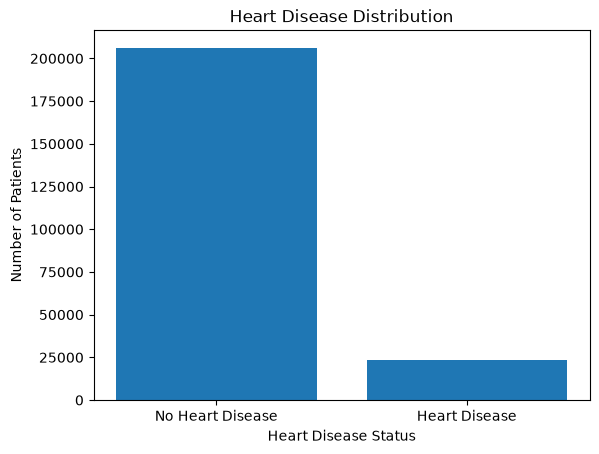

In [16]:
target_counts = df["HeartDiseaseorAttack"].value_counts().sort_index()
plt.bar(["No Heart Disease", "Heart Disease"],target_counts.values)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")
plt.show()

## Plot Anlaysis
imbalance  is visible on the chart between the two target classes.
There are many more cases that don’t have any heart disease or heart attack than cases which have heart disease or heart attack.

## BMI Distribution
It used to study the distribution of BMI data is the histogram.
In this way, we can analyze the center, spread, and shape of the BMI distribution, and determine if there are any outliers.

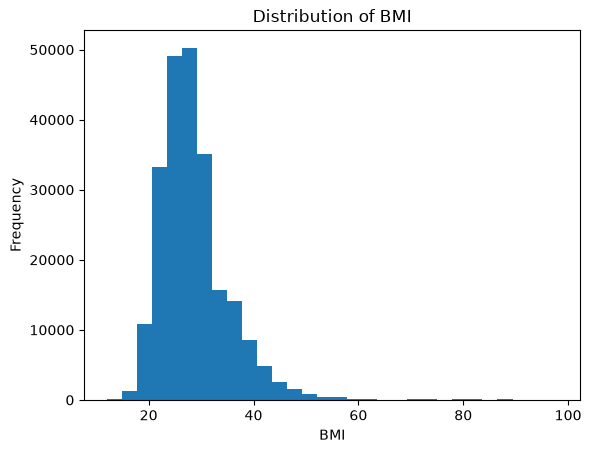

mean    28.68567
std      6.78636
min     12.00000
50%     27.00000
max     98.00000
Name: BMI, dtype: float64


In [20]:
plt.hist(df["BMI"], bins=30)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()
print(df["BMI"].describe()[['mean', 'std', 'min', '50%', 'max']])

The BMI histogram presents how BMI values are distributed in the data set.
This distribution shape may be compared to the descriptive statistics previously computed.
The distribution is right-skewed, meaning most values lie in the normal/overweight category while the tail stretches to larger numbers.
The tail at the right side represents very high outliers that need to be considered before fitting the model for sensitive applications.
Most of the data lies in the range of 25-30 BMI, which represents the overweight group.
When comparing this histogram to descriptive statistics, we see that the mean is greater than the median due to skewness.

## Poor Mental Health Days Distribution
MentHlth is the number of days in the previous 30 days in which the mental health of the patient was poor.
A histogram can be used to learn about the distribution of these values among patients.

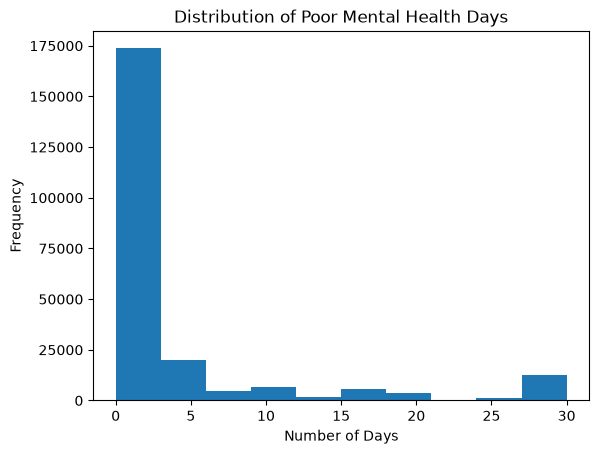

In [21]:
plt.hist(df["MentHlth"])
plt.title("Distribution of Poor Mental Health Days")
plt.xlabel("Number of Days")
plt.ylabel("Frequency")
plt.show()

The shape of the distribution is highly positively skewed, demonstrating that most people have zero or very few poor mental health days.
There is an enormous spike at zero, which means that most people did not have any poor mental health days within the last month.
There is also a spike at 30 days, reflecting the experience of those who had poor mental health almost every day.

## Number of Poor Physical Health Days
PhysHlth refers to the number of poor physical health days in the last 30 days.
A histogram can be used to detect the most frequent values and the general distribution.

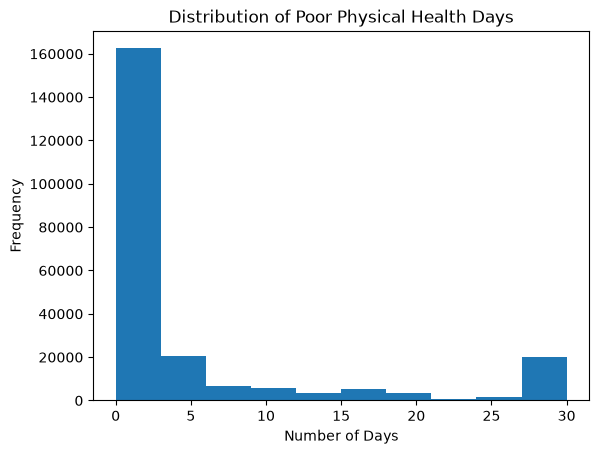

In [22]:
plt.hist(df["PhysHlth"])
plt.title("Distribution of Poor Physical Health Days")
plt.xlabel("Number of Days")
plt.ylabel("Frequency")
plt.show()

The distribution is highly skewed to the right since most people had either none or very few bad physical health days.
There is a huge peak at zero because most people had no bad physical health days in the last 30 days.
There is a small cluster close to 30 days indicating that there were people who experienced poor physical health almost every day.

## BMI Boxplot
Box plots are useful for describing the distribution of BMI and detecting any outliers.
The box plot shows the interquartile range and the whiskers are used to detect the presence of any outliers.

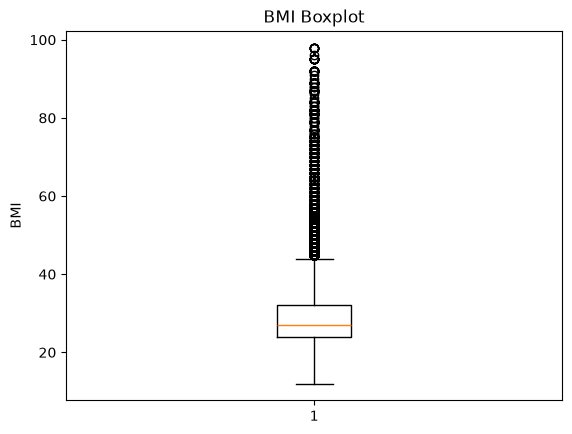

In [23]:
plt.boxplot(df["BMI"])
plt.title("BMI Boxplot")
plt.ylabel("BMI")
plt.show()

The box plot highlights the median BMI and the interquartile range where the majority of data points lie.
Numerous individual points extending above the upper whisker clearly confirm the presence of high-value outliers.

## General Health
### General Health Levels
GenHlth is a categorically ordinal variable indicating the state of general health of the participant.
A bar graph is suitable since the values indicate distinct ordered categories as opposed to continuous variables.

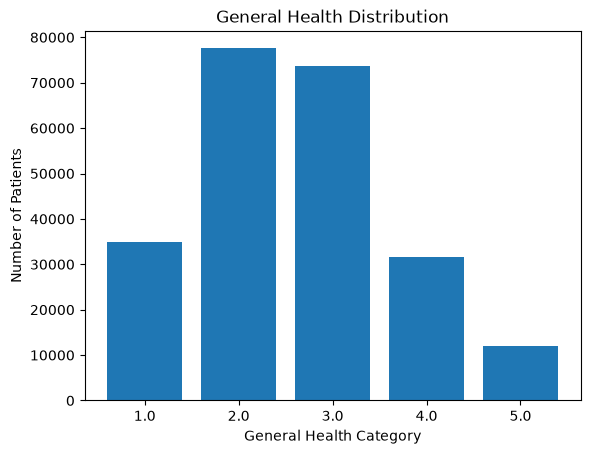

In [24]:
genhlth_counts = df["GenHlth"].value_counts().sort_index()
plt.bar(genhlth_counts.index.astype(str),genhlth_counts.values)
plt.title("General Health Distribution")
plt.xlabel("General Health Category")
plt.ylabel("Number of Patients")
plt.show()

Figure illustrates the distribution of respondents into five general categories of health.
This offers a better understanding of the prevalence of different health statuses reported.

## Diabetes
### Diabeties Status Frequency
The Diabetes field holds discrete data on different diabeties statuses.
A histogram can be used to compare observation frequencies for all categories.

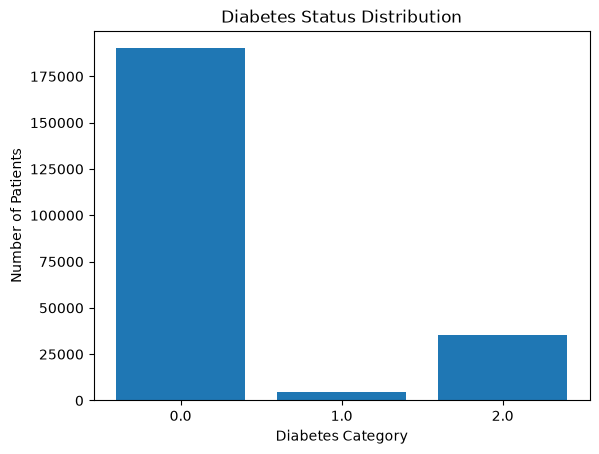

In [25]:
diabetes_counts = df["Diabetes"].value_counts().sort_index()
plt.bar(diabetes_counts.index.astype(str),diabetes_counts.values)
plt.title("Diabetes Status Distribution")
plt.xlabel("Diabetes Category")
plt.ylabel("Number of Patients")
plt.show()

It is evident from the bar chart that there is class imbalance, where category zero has the highest number of occurrences.
Category two denotes a fairly large number of instances, while category one has the smallest number of instances.

## High Blood Pressure vs Heart Disease
Let’s take a step forward from univariate analysis and compare two variables.
HighBP is compared with HeartDiseaseorAttack to see whether the distribution of heart disease varies based on the presence or absence of high blood pressure

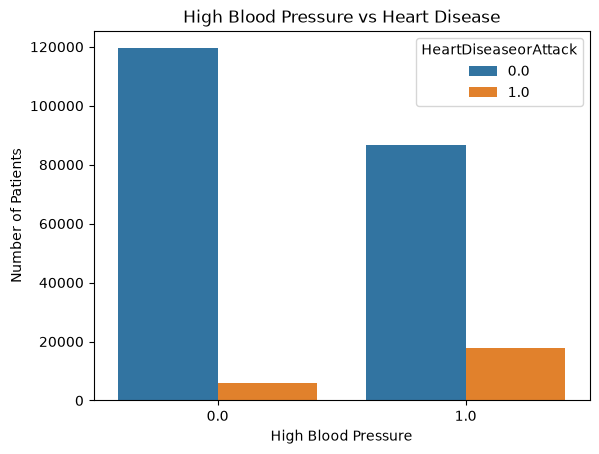

In [47]:
sns.countplot(data=df,x="HighBP",hue="HeartDiseaseorAttack")
plt.title("High Blood Pressure vs Heart Disease")
plt.xlabel("High Blood Pressure")
plt.ylabel("Number of Patients")
plt.show()

The countplot  shows the number of heart disease or attacks based on people who have or do not have high blood pressure.
People with high blood pressure are found to have a higher number of heart disease than people without high blood pressure.

## Smoking vs Heart Disease
moking status is compared with the target variable to study any differences in heart disease distribution in smokers and non-smokers.

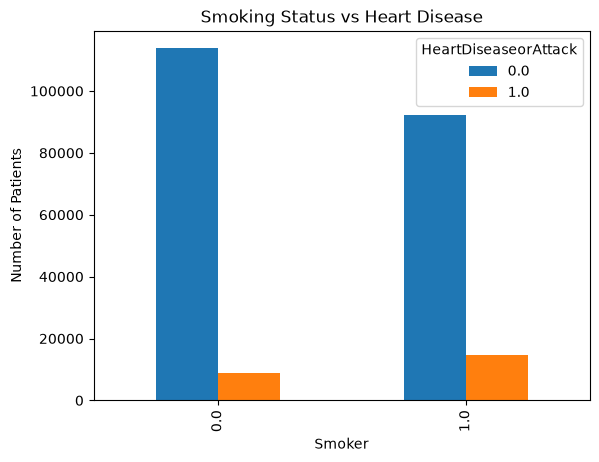

In [33]:
smoker_heart = pd.crosstab(df["Smoker"],df["HeartDiseaseorAttack"])
smoker_heart.plot( kind="bar")
plt.title("Smoking Status vs Heart Disease")
plt.xlabel("Smoker")
plt.ylabel("Number of Patients")
plt.show()

Smokers show a higher relative proportion and count of heart disease occurrences compared to non-smokers.

## Physical Activity vs Heart Disease
Physical activity is compared with the target variable in order to test whether the distribution of heart disease varies among respondents that are physically active or inactive.

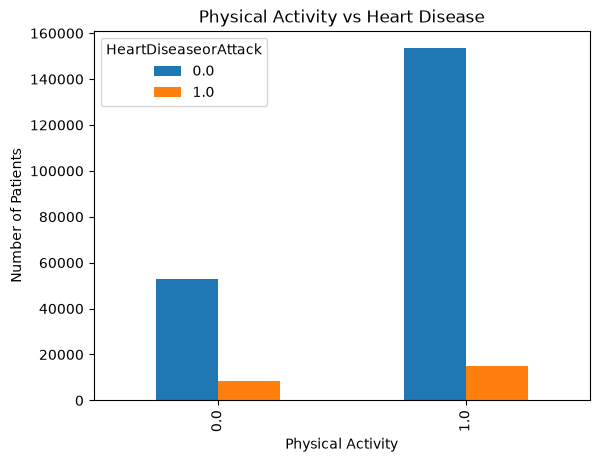

In [34]:
activity_heart = pd.crosstab(df["PhysActivity"],df["HeartDiseaseorAttack"])
activity_heart.plot(kind="bar")
plt.title("Physical Activity vs Heart Disease")
plt.xlabel("Physical Activity")
plt.ylabel("Number of Patients")
plt.show()

The grouped bar chart demonstrates the comparison between heart disease or attack rates according to physical activity.
People who engage themselves in physical activities have more counts of records because of the distribution size.

## Correlation
### Correlation Analysis
Correlation analysis can be used as another exploratory tool for studying connections between the coded variables.
Correlation with HeartDiseaseorAttack will help get an initial idea of which variables show stronger or weaker linear correlations with the target variable.
Since many variables are binary or ordinal categorical variables that are numerically coded, the results of correlation should be considered carefully.

In [35]:
Correlation = df.corr(numeric_only=True)
Correlation["HeartDiseaseorAttack"].sort_values(ascending=False)

HeartDiseaseorAttack    1.000000
GenHlth                 0.246411
Age                     0.223626
DiffWalk                0.202779
HighBP                  0.201271
Stroke                  0.198863
HighChol                0.176279
Diabetes                0.170816
PhysHlth                0.170473
Smoker                  0.105154
Sex                     0.089717
MentHlth                0.052756
CholCheck               0.049995
BMI                     0.039926
AnyHealthcare           0.025899
NoDocbcCost             0.022076
Fruits                 -0.007128
Veggies                -0.027330
HvyAlcoholConsump      -0.035453
PhysActivity           -0.073267
Education              -0.082466
Income                 -0.122908
Name: HeartDiseaseorAttack, dtype: float64

The variables General Health, Age, Difficulty in walking, and High blood pressure are found to have high positive correlation values with heart disease or attack.
The variables such as Income and Education have negative correlation values with heart disease.

## Heatmap Visualization
It can quickly determine which variables have a greater association with one another or with the dependent variable based on how intense their corresponding colors are in their respective rows or columns.

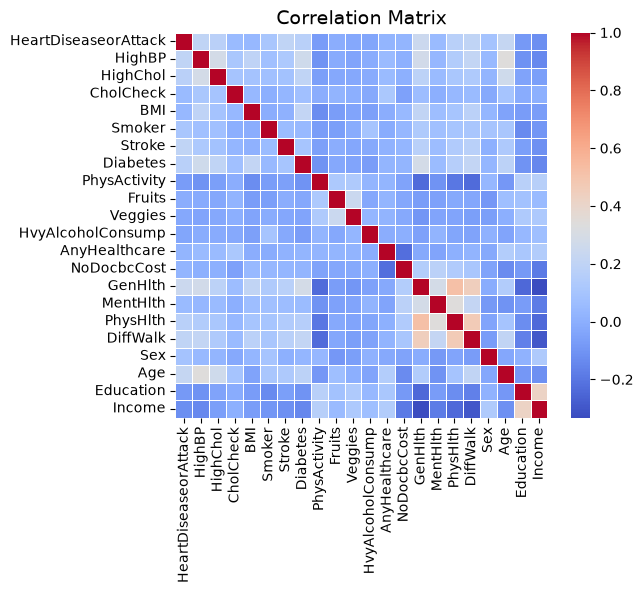

In [42]:
plt.figure(figsize=(6, 5))
sns.heatmap(Correlation, annot=False, cmap='coolwarm', fmt=".2f", xticklabels=Correlation.columns, yticklabels=Correlation.columns, cbar=True, linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

The correlation heatmap visualizes the pairwise linear relationships across all numeric variables in the dataset.
Most variable pairs show weak linear correlation, clustered near zero, while the diagonal displays a perfect correlation of 1.0 for each variable with itself.

## BMI Distribution by Heart Disease Status
A boxplot is used to compare the distribution of BMI between patients with and without reported heart disease or heart attack.
This visualization helps us compare the median, spread, and potential outliers of BMI across the two target classes.

## EDA Findings
From the descriptive statistics and visualized information, the following observations can be made:
- The response variable HeartDiseaseorAttack is unbalanced, with more data belonging to the no-heart-disease category.
- The numeric variables BMI, MentHlth, and PhysHlth have different distributions and variability levels.
- The histograms indicate concentration in some areas and allow to identify potential extremes.
- The BMI boxplot allows identifying potential outliers that need further investigation, not immediate elimination.
- Categorical and ordinal features have different distributions depending on their encoded values.
- Comparing HighBP, Smoker, PhysActivity and the response variable offers valuable exploratory insights into the differences in heart-disease classes.
- Correlation offers preliminary insights into relationships between features and the response variable, but correlation does not equal causality.

## Supervised Learning: Problem Formulation and Baseline Classifier

Following exploratory data analysis, the next step in this Project is the formulation of the machine learning problem as well as building the initial baseline classifier.
The task is to apply the provided health features to predict whether or not the patient has had any heart disease or a heart attack.
**As the target feature HeartDiseaseorAttack consists of two classes, the problem is a binary classification task.**
In this part of the assignment, the dataset will be preprocessed for the purpose of supervised learning.

## Train/Test Split
The first step before fitting the model is splitting the dataset into two:
- Training Set: the set that will be used for fitting the machine learning model.
- Test Set: the set that will be used for testing the performance of the machine learning model.
It is crucial to distinguish between the two, since it is not possible to test the performance of a machine learning model using the data it was fitted with,it is necessary to perform the stratified split, since the target variable is imbalanced.
Dataset is split into:
- X: The inputs which will be used as inputs for the model.
- y: The output which the model will try to predict.
Target column is excluded from x because we don’t want the model to take answer as an input for itself.

In [22]:
x = df.drop(["HeartDiseaseorAttack"],axis=1)
y = df["HeartDiseaseorAttack"]
print("x shape:", X.shape)
print("y shape:", y.shape)

x shape: (229781, 21)
y shape: (229781,)


## Split the Dataset
The dataset will be split into:
- 80% train data
- 20% test data
Here, a random_state value is provided to reproduce the split.

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,)
print("x Training set:", x_train.shape)
print("x Testing set:", x_test.shape)
print(" y Training set:", y_train.shape)
print(" y Testing set:", y_train.shape)


x Training set: (183824, 21)
x Testing set: (45957, 21)
 y Training set: (183824,)
 y Testing set: (183824,)


## Feature Scaling
Logistic Regression can use feature scaling as the variables differ in their numerical scales.
For instance, the BMI variable will differ in scale compared to variables like Age, Education, or Income.
StandardScaler rescales the features to a distribution with a mean close to 0 and a standard deviation close to 1.
The scaling is done using only the training dataset and then used for the test dataset to prevent data leakage.

In [25]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Baseline Classifier - Logistic Regression
 why Logistic Regression has been chosen as the baseline classifier?
- It is meant to solve classification problems.
- It is an easy and understandable classifier.
- It gives a good baseline when compared to more complicated classifiers.
- It is capable of providing probabilities of classes.
The baseline classifier is going to be trained using the training dataset and tested using the unseen testing dataset.

In [26]:
baseline_model = LogisticRegression(max_iter=1000,random_state=42)
baseline_model.fit(x_train_scaled, y_train)
y_predict_baseline = baseline_model.predict(x_test_scaled)

## Baseline Accuracy
Accuracy is an indicator of the fraction of correctly classified samples out of all tested samples,accuracy may be an insufficient indicator for this dataset since the classes are unbalanced.
**This is why accuracy will be provided alongside precision, recall, and F1-score.**

In [29]:
baseline_accuracy = accuracy_score(y_test, y_predict_baseline)
baseline_precision = precision_score(y_test, y_predict_baseline)
baseline_recall = recall_score(y_test, y_predict_baseline)
baseline_f1 = f1_score(y_test, y_predict_baseline)
print(f"Accuracy : {baseline_accuracy}")
print(f"Precision: {baseline_precision}")
print(f"Recall   : {baseline_recall}")
print(f"F1-score : {baseline_f1}")

Accuracy : 0.9004286615749505
Precision: 0.553742802303263
Recall   : 0.123080204778157
F1-score : 0.2013961605584642


## Baseline Evaluation Results
Upon evaluation of the baseline model on the test dataset, the following performance results have been obtained:
* Accuracy (0.9004): Seems to be very high, but may not be relevant to this particular dataset owing to class imbalance.
* Precision (0.5537): Shows the proportion of true positives among all predictions made by the model.
* Recall (0.1230): Reflects that there are serious problems with recognizing positives because of class imbalance.
* F1-score (0.2013): A combination of precision and recall that reveals poor performance of the baseline on the minority class.

In [30]:
print(classification_report(y_test,y_predict_baseline,target_names=["No Heart Disease", "Heart Disease"]))

                  precision    recall  f1-score   support

No Heart Disease       0.91      0.99      0.95     41269
   Heart Disease       0.55      0.12      0.20      4688

        accuracy                           0.90     45957
       macro avg       0.73      0.56      0.57     45957
    weighted avg       0.87      0.90      0.87     45957



## Analysis of Classification Report
The classification report highlights the performance of the model on each class as follows:
* No Heart Disease (Majority Class): The model has a very good performance in this case, with a **Precision of 0.91** and a **Recall of 0.99**. This is due to the fact that most of the samples belong to this class.
* Heart Disease (Minority Class):The model performs poorly in this case, with a **Recall of 0.12**. It is unable to recognize 88% of "Heart Disease" cases.
* Support: The imbalance of classes is evident here, with 41,269 samples in the "No Heart Disease" class and just 4,688 samples in the "Heart Disease" class.
* Macro/Weighted Averages: The difference in the averages shows that even though the model has an overall accuracy of 0.90, it cannot predict the minority class at all.
**The baseline metrics will be used later to compare the performance of the second classifier** .

## Model Comparison and Evaluation
Having chosen a logistic regression model as a benchmark model, we will then evaluate a second classification model.
**The goal at this stage is to evaluate two models of classification by applying the same set of training and test data.**
Apart from the above metrics, cross-validation and the confusion matrix will be used for evaluation.

## Random Forest(Second Classifier)
Random Forest is chosen as the second classifier,while the Logistic Regression classifier is linear in nature, the Random Forest algorithm is composed of decision trees.
Random Forest is able to identify nonlinear relationships among features.
For this reason, it is a good classifier to compare with Logistic Regression due to the presence of various health, lifestyle, and demographic features in the data set.

## Train Random Forest

In [36]:
random_forest_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
random_forest_model.fit(x_train, y_train)
y_predict_rf = rf_model.predict(x_test)

## Random Forest Model Evaluation
Random Forest model performance will be evaluated using the same metrics as those used to evaluate Logistic Regression performance,the use of the same testing data and evaluation metrics will ensure that the comparison is consistent.

In [37]:
random_forest_accuracy = accuracy_score(y_test, y_predict_rf)
random_forest_precision = precision_score(y_test, y_predict_rf)
random_forest_recall = recall_score(y_test, y_predict_rf)
random_forest_f1 = f1_score(y_test, y_predict_rf)
print(f"Accuracy : {random_forest_accuracy}")
print(f"Precision: {random_forest_precision}")
print(f"Recall   : {random_forest_recall}")
print(f"F1-score : {random_forest_f1}")

Accuracy : 0.8948147181060556
Precision: 0.43834459459459457
Recall   : 0.11070819112627986
F1-score : 0.17677111716621252


## Random Forest Model Performance
* Accuracy (0.8948): In comparison with the baseline, the accuracy is high; however, it does not show the actual effectiveness of the model in relation to the minority class.
* Precision (0.4383): It is evident that out of all the cases considered positive by the model, about 43.8% are actually positive.
* Recall (0.1107): Only 11% of actual "Heart Disease" cases were found by the model.
* F1-score (0.1767): Shows the balance between precision and recall.

In [39]:
print(classification_report(y_test,y_predict_rf,target_names=["No Heart Disease", "Heart Disease"]))

                  precision    recall  f1-score   support

No Heart Disease       0.91      0.98      0.94     41269
   Heart Disease       0.44      0.11      0.18      4688

        accuracy                           0.89     45957
       macro avg       0.67      0.55      0.56     45957
    weighted avg       0.86      0.89      0.87     45957



## Random Forest Classification Report Analysis
From the classification report of the Random Forest algorithm, one can observe consistent performance problems that stem from the class imbalance of our data:
* Class "No Heart Disease": Our model retains a high level of performance by providing **Precision (0.91)** and **Recall (0.98)** results, similar to those received in the base algorithm.
* Class "Heart Disease": The model is not capable of generalizing with a **Precision of 0.44** and very low **Recall of 0.11**. Hence, the default Random Forest is also unable to detect the majority of "Heart Disease" cases.
* Support Calculation: The support is still high for "No Heart Disease" samples (41,269 vs. 4,688).
* Weighted Averages: The relatively high level of the weighted average (0.87) stems from the domination of the "No Heart Disease" samples.

## Cross-Validation
One test/train split will yield one performance measurement of the model,to get a more accurate measurement, cross-validation technique is employed.
**5-fold cross-validation** entails splitting the training set into five folds.
The four folds will be used for training, while the other will be used to validate the model. This procedure is repeated five times so that each fold will serve as the validation set.Finally, the five measurements will be averaged out.
**Cross-validation is used to ascertain if the model's performance is fairly consistent over all splits of the training data**.

### Why Stratified K-Fold
As there is imbalance in the target variable, stratification of folds is applied instead of regular K-Fold.Stratification maintains the same proportion of two classes of the target variable in the folds.
This is necessary since each fold must have representative samples from both the classes.

In [44]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
logistic_cv_scores = cross_val_score(baseline_model,x_train_scaled,y_train,cv=cv,scoring="f1")
print(logistic_cv_scores)
print(f"Mean CV F1-score: {logistic_cv_scores.mean()}")
print(f"Std CV F1-score : {logistic_cv_scores.std()}")

[0.20144804 0.20401195 0.20208024 0.20103315 0.20064586]
Mean CV F1-score: 0.20184384633399216
Std CV F1-score : 0.0011836919911093675


## Random Forest CV
Similarly, the 5-fold stratified cross validation technique is used for Random Forest as well,with the same number of folds and the same evaluation criteria, it ensures that both models are being compared fairly.

In [46]:
rf_cv_scores = cross_val_score(rf_model,x_train,y_train,cv=cv,scoring="f1",n_jobs=-1)
print(rf_cv_scores)
print(f"Mean CV F1-score: {rf_cv_scores.mean()}")
print(f"Std CV F1-score : {rf_cv_scores.std()}")

[0.17340801 0.16304811 0.16312802 0.15684612 0.16712042]
Mean CV F1-score: 0.16471013483259336
Std CV F1-score : 0.005451065501137987


## Cross Validation Explanation
The mean F1-score is the mean performance over the five validation folds.
The standard deviation is the degree to which performance varies between folds.
Low standard deviation implies that the model performs consistently on different subsets of the training set.
Therefore, cross validation gives us further insight into model stability besides the performance on the test set.
Based on the 5-fold stratified cross-validation using the **F1-score** metric:
* Individual Fold Scores: [0.1734, 0.1630, 0.1631, 0.1568, 0.1671]
* Mean CV F1-score (0.1647): Confirms that the model's poor performance on the minority class is consistent and not a result of an unfortunate train/test split.
* Standard Deviation (0.0055): Very low standard deviation indicates high stability and reliability across different subsets of the data; the model generalizes its behavior consistently.
The cross-validation results reinforce our earlier findings. While the Random Forest model is stable (low variance across folds), its low F1-score highlights that model architecture alone cannot overcome the severe class imbalance without proper data preprocessing 

## Confusion Matrix
A confusion matrix offers a more comprehensive look into the classification output.
There are four possible results:
- True Negative (TN): No heart disease is predicted accurately.
- False Positive (FP): Heart disease is predicted where there is no heart disease.
- False Negative (FN): No heart disease is predicted when there is heart disease.
- True Positive (TP): Heart disease is predicted correctly.
In this study, the False Negatives are especially crucial as they are the instances of patients with known heart disease that the model did not detect.

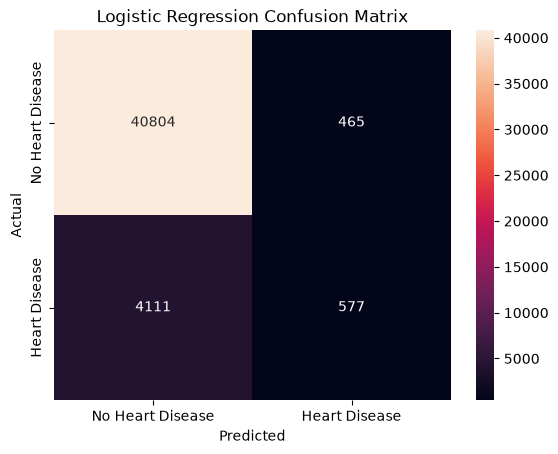

In [49]:
confusion_matrix_logistic = confusion_matrix(y_test, y_predict_baseline)
sns.heatmap(confusion_matrix_logistic ,annot=True,fmt="d",xticklabels=["No Heart Disease", "Heart Disease"],yticklabels=["No Heart Disease", "Heart Disease"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

###  Plot Analysis (Logistic Regression)

The confusion matrix visually describes the prediction results versus the actual class labels:
* True Negatives (TN = 40804): The number of instances where the algorithm correctly predicted "No Heart Disease". It is extremely high because of the prevalence of the majority class.
* False Positives (FP = 465): Instances that were incorrectly classified as "Heart Disease" (Type I error).
* False Negatives (FN = 4111): (Type II error)This is a critical failure point.
* True Positives (TP = 577): Instances where the model correctly classified the cases as "Heart Disease". 
Out of the 4,688 total instances of heart disease, the algorithm was able to correctly classify only 577, with 4,111 cases left out (False Negatives). This visually explains why the Recall for the minority class is extremely low (12%).

## Confusion Matrix for Random Forests
Confusion matrix analysis is performed for the random forest model as well,through comparison, we can see the differences between the two models in terms of classifying positive and negative cases.

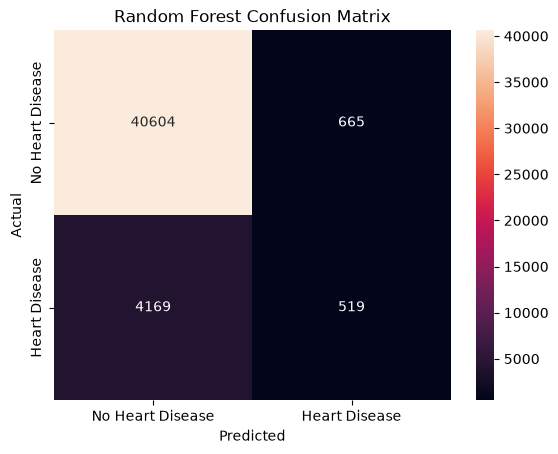

In [51]:
confusion_matrix_rf = confusion_matrix(y_test, y_predict_rf)
sns.heatmap(confusion_matrix_rf,annot=True,fmt="d",xticklabels=["No Heart Disease", "Heart Disease"],yticklabels=["No Heart Disease", "Heart Disease"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Plot Analysis (Random Forest)
The analysis of how Random Forest predicts compared to the actual class label shows how poorly it performs with regards to imbalanced classes:
* True Negative (TN = 40604): The model correctly identifies the vast majority of negative cases ("No Heart Disease").
* False Positive (FP = 665): It wrongly identifies a few healthy patients as those suffering from heart disease (Type I Error).
* False Negative (FN = 4169): This is the most significant problem. The model fails to identify almost all patients that actually suffer from heart disease (Type II Error).
* True Positive (TP = 519): The model accurately identifies only a small percentage of the total heart disease patients.

###  Comparison of Confusion Matrices (Logistic Regression and Random Forest)
The comparison of the confusion matrices in the context of the Logistic Regression baseline versus the Random Forest classifier offers us some interesting observations:
Conclusion about the Matrices: The transition from the linear classifier (Logistic Regression) to the non-linear ensemble classifier (Random Forest) did not address the main problem associated with the imbalance of the dataset. Both classifiers have a high number of False Negatives (miss more than 4,000 sick people), which means that only changes in architecture will not help here.

## Comparison DataFrame

In [57]:
comparison = pd.DataFrame({"Model": ["Logistic Regression","Random Forest"],"Accuracy": [baseline_accuracy,random_forest_accuracy],"Precision": [baseline_precision,random_forest_precision],"Recall": [baseline_recall,random_forest_recall],"F1-score": [baseline_f1,random_forest_f1],"CV Mean F1": [logistic_cv_scores.mean(),rf_cv_scores.mean()]})
comparison

,Model,Accuracy,Precision,Recall,F1-score,CV Mean F1
0,Logistic Regression,0.900429,0.553743,0.123080,0.201396,0.201844
1,Random Forest,0.894815,0.438345,0.110708,0.176771,0.164710


## Visual Comparison of the Models
The bar graph helps in comparing the key performance measures of both logistic regression and random forest,this will make it easy to differentiate between accuracy, precision, recall, and F1 score.

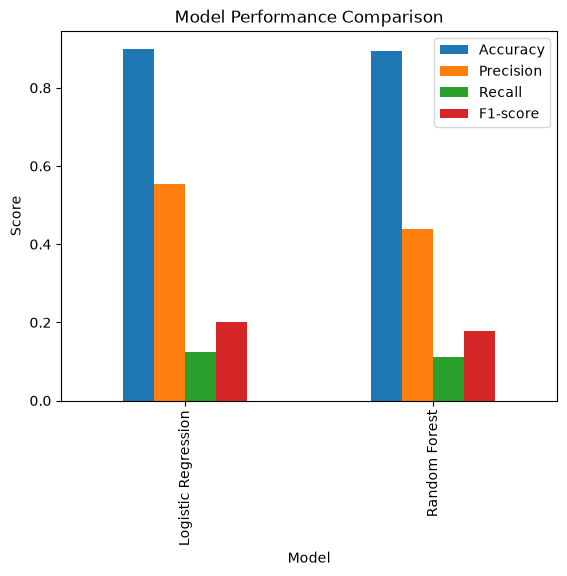

In [58]:
comparison_plot = comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]]
comparison_plot.plot(kind="bar",)
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.show()

## Determine Best Model Based on F1-score
Because the dataset is imbalanced, F1-score is used as an important metric for comparing the two classifiers,the model with the highest test-set F1-score will be identified below.

In [59]:
best_model = comparison.loc[comparison["F1-score"].idxmax(),"Model"]
best_f1 = comparison["F1-score"].max()
print(f"Best model based on test F1-score: {best_model}")
print(f"F1-score: {best_f1}")

Best model based on test F1-score: Logistic Regression
F1-score: 0.2013961605584642


###  Best Model Selection Result
From the comparison of the test-set F1-score, the **Logistic Regression** model is the one selected to be the best model among the two models - Random Forest - which has a test F1-score of **0.2014**.
Although Logistic Regression is chosen here, the low F1-score suggests that both models fail to perform well for the minority class,**confirming the need for handling data imbalance in subsequent steps**.